# Yapay Sinir Ağları: Keras ve PyTorch
**Kutay Kalay** · SoftITo Yapay Zeka · 24.09.2026

Aynı ikili sınıflandırma problemini (meme kanseri: kötü / iyi huylu) aynı ağ yapısıyla iki kütüphanede çözüyoruz:
1. **Keras:** `fit()` eğitim döngüsünü bizim yerimize yazar.
2. **PyTorch:** Eğitim döngüsünü kendimiz yazarız.

Ağ: `30 özellik → Dense(16, relu) → Dropout → Dense(8, relu) → Dropout → Dense(1, sigmoid)`

In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, ConfusionMatrixDisplay

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

## Veri: train / validation / test
- **train:** Ağırlıklar bununla öğrenilir.
- **validation:** Eğitim sırasında "ne zaman durmalı?" sorusu buna bakarak cevaplanır.
- **test:** En sonda, bir kez kullanılır.

Sinir ağları ölçeğe çok duyarlıdır. Scaler'ı sadece train'e fit ediyoruz.

In [2]:
X, y = load_breast_cancer(return_X_y=True)

X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(X_tv, y_tv, test_size=0.2, stratify=y_tv, random_state=SEED)

olcek = StandardScaler().fit(X_tr)
X_tr, X_val, X_te = olcek.transform(X_tr), olcek.transform(X_val), olcek.transform(X_te)
print("train:", X_tr.shape, " val:", X_val.shape, " test:", X_te.shape)

train: (364, 30)  val: (91, 30)  test: (114, 30)


## 1. Keras
**Katmanlar:**
- `Dense`: Tam bağlı katman. Her nöron bir önceki katmanın tüm çıktılarını alır.
- `relu`: Negatif değerleri sıfırlar.
- `Dropout(0.2)`: Eğitimde nöronların %20'sini rastgele kapatır, ezberlemeyi zorlaştırır.
- `sigmoid`: Son çıktıyı 0–1 arasına sıkıştırır, yani olasılık verir.

In [3]:
keras_model = keras.Sequential([
    layers.Input(shape=(X_tr.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

**compile:**
- `optimizer`: Ağırlıkları nasıl güncelleyeceğimiz (Adam).
- `loss`: Hatayı nasıl ölçeceğimiz (ikili sınıflandırma için binary cross-entropy).
- `metrics`: Eğitim sırasında izlenecek başarı ölçüleri.

**Callback'ler:**
- `EarlyStopping`: Validation loss 10 epoch boyunca iyileşmezse eğitimi durdurur ve en iyi ağırlıklara geri döner.
- `ReduceLROnPlateau`: İlerleme yavaşlayınca öğrenme hızını yarıya indirir.

In [4]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

callbackler = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
]

gecmis = keras_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=32,
    callbacks=callbackler, verbose=0,
)
print("Eğitim", len(gecmis.history["loss"]), "epoch sonra durdu.")

Eğitim 80 epoch sonra durdu.


**Öğrenme eğrileri:** Train ve validation eğrileri birlikte iniyorsa model öğreniyordur.
Train düşmeye devam ederken validation yükselmeye başlarsa model overfit oluyordur. EarlyStopping tam bu noktada devreye girer.

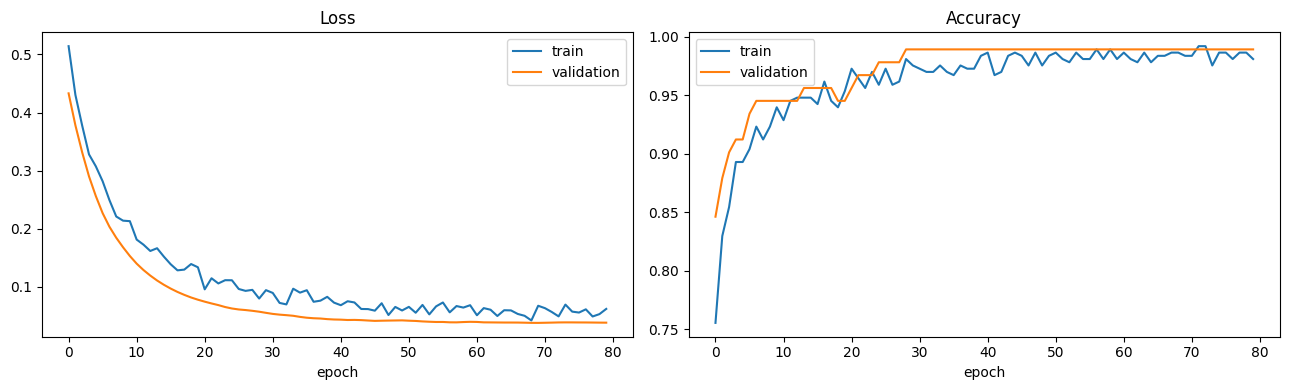

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(gecmis.history["loss"], label="train")
axes[0].plot(gecmis.history["val_loss"], label="validation")
axes[0].set(title="Loss", xlabel="epoch")
axes[0].legend()
axes[1].plot(gecmis.history["accuracy"], label="train")
axes[1].plot(gecmis.history["val_accuracy"], label="validation")
axes[1].set(title="Accuracy", xlabel="epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

Keras test → loss: 0.1204 | accuracy: 0.9649 | AUC: 0.9907


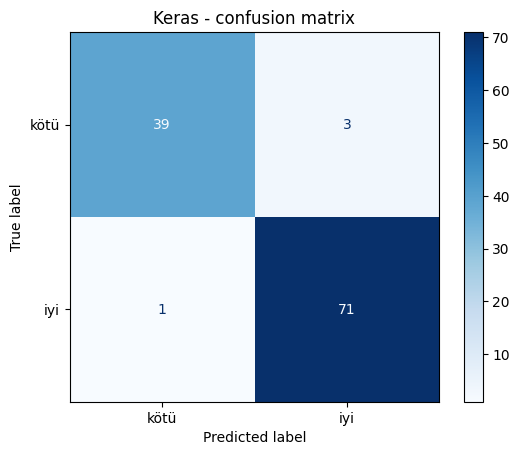

              precision    recall  f1-score   support

  kötü huylu       0.97      0.93      0.95        42
   iyi huylu       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [6]:
test_loss, test_acc, test_auc = keras_model.evaluate(X_te, y_te, verbose=0)
print(f"Keras test → loss: {test_loss:.4f} | accuracy: {test_acc:.4f} | AUC: {test_auc:.4f}")

keras_olasilik = keras_model.predict(X_te, verbose=0).ravel()
keras_tahmin = (keras_olasilik >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_te, keras_tahmin, display_labels=["kötü", "iyi"], cmap="Blues")
plt.title("Keras - confusion matrix")
plt.show()
print(classification_report(y_te, keras_tahmin, target_names=["kötü huylu", "iyi huylu"]))

## 2. PyTorch
PyTorch'ta her şey **tensor**. Veriyi tensöre çevirip `DataLoader` ile 32'lik batch'lere bölüyoruz.
Hedefi `(n,)` yerine `(n, 1)` şekline getirmek için `unsqueeze(1)` kullanıyoruz, çünkü modelin çıktısı da `(n, 1)`.

In [7]:
def tensor(a):
    return torch.tensor(a, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(tensor(X_tr), tensor(y_tr).unsqueeze(1)), batch_size=32, shuffle=True)
X_val_t, y_val_t = tensor(X_val), tensor(y_val).unsqueeze(1)
X_te_t = tensor(X_te)

**Model sınıfı:** `nn.Module`'den türetilir. `__init__` içinde katmanlar tanımlanır, `forward` içinde verinin nasıl akacağı yazılır.

Son katmanda sigmoid **yok**. `BCEWithLogitsLoss`, sigmoid ile binary cross-entropy'yi tek adımda ve sayısal olarak daha kararlı biçimde yapar.
Olasılık gerektiğinde çıktıya `torch.sigmoid` uyguluyoruz.

In [8]:
class SinirAgi(nn.Module):
    def __init__(self, n_ozellik):
        super().__init__()
        self.katmanlar = nn.Sequential(
            nn.Linear(n_ozellik, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, 8), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.katmanlar(x)

torch_model = SinirAgi(X_tr.shape[1])
kayip_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)
print(torch_model)

SinirAgi(
  (katmanlar): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


**Eğitim döngüsü:** Keras'ın `fit()` fonksiyonunun içinde olanları burada elle yazıyoruz. Her batch için:
1. `optimizer.zero_grad()`: Önceki gradyanları sıfırla.
2. `model(xb)`: İleri yayılım (tahmin).
3. `loss.backward()`: Geri yayılım (gradyanları hesapla).
4. `optimizer.step()`: Ağırlıkları güncelle.

Her epoch sonunda validation loss'a bakıyoruz ve EarlyStopping'i de kendimiz yazıyoruz.
`model.train()` / `model.eval()`: Dropout sadece eğitimde açık olmalı, bu yüzden moda göre açılıp kapanıyor.

In [9]:
torch_gecmis = {"loss": [], "val_loss": []}
en_iyi_kayip, sabir, bekleme = float("inf"), 10, 0

for epoch in range(200):
    torch_model.train()
    toplam = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        kayip = kayip_fn(torch_model(xb), yb)
        kayip.backward()
        optimizer.step()
        toplam += kayip.item() * len(xb)

    torch_model.eval()
    with torch.no_grad():
        val_kayip = kayip_fn(torch_model(X_val_t), y_val_t).item()

    torch_gecmis["loss"].append(toplam / len(train_loader.dataset))
    torch_gecmis["val_loss"].append(val_kayip)

    if val_kayip < en_iyi_kayip - 1e-4:
        en_iyi_kayip, bekleme = val_kayip, 0
        en_iyi_agirliklar = copy.deepcopy(torch_model.state_dict())
    else:
        bekleme += 1
        if bekleme >= sabir:
            print(f"Erken durdurma: epoch {epoch + 1}")
            break

torch_model.load_state_dict(en_iyi_agirliklar)

Erken durdurma: epoch 103


<All keys matched successfully>

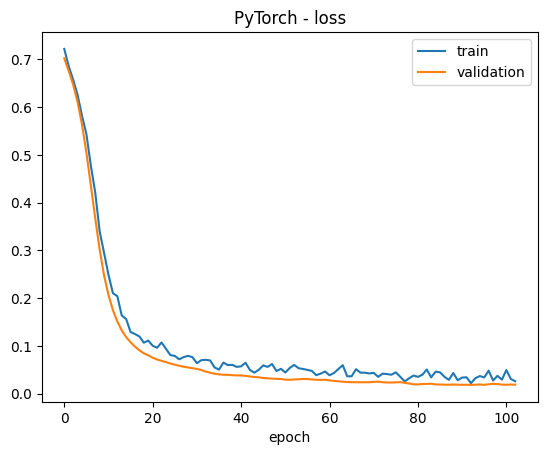

In [10]:
plt.plot(torch_gecmis["loss"], label="train")
plt.plot(torch_gecmis["val_loss"], label="validation")
plt.title("PyTorch - loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [11]:
torch_model.eval()
with torch.no_grad():
    torch_olasilik = torch.sigmoid(torch_model(X_te_t)).numpy().ravel()
torch_tahmin = (torch_olasilik >= 0.5).astype(int)

print(classification_report(y_te, torch_tahmin, target_names=["kötü huylu", "iyi huylu"]))

              precision    recall  f1-score   support

  kötü huylu       0.97      0.93      0.95        42
   iyi huylu       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 3. Karşılaştırma
Aynı mimari ve aynı veriyle iki kütüphane benzer sonuçlar vermeli. Küçük farklar rastgele başlangıç ağırlıklarından ve batch sırasından gelir.

In [12]:
pd.DataFrame({
    "Keras": [accuracy_score(y_te, keras_tahmin), roc_auc_score(y_te, keras_olasilik), len(gecmis.history["loss"])],
    "PyTorch": [accuracy_score(y_te, torch_tahmin), roc_auc_score(y_te, torch_olasilik), len(torch_gecmis["loss"])],
}, index=["test accuracy", "test ROC-AUC", "epoch sayısı"]).round(4)

,Keras,PyTorch
test accuracy,0.9649,0.9649
test ROC-AUC,0.9907,0.9888
epoch sayısı,80.0000,103.0000
